**Team 65**

**CS23B2043**
**Shishir Kumar Reddy Ambala**

**CS23B1004**
**Anumalasetty Sohan Kumar**

# Deep Learning Lab Assignment - 3
## MNIST Digit Classification using CNN


## 1. Importing Required Modules

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tensorflow.keras.datasets import mnist
import time

## 2. Loading and Exploring the MNIST Dataset

In [48]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

print("Training set shape :", X_train_raw.shape)
print("Training labels    :", y_train_raw.shape)
print("Test set shape     :", X_test_raw.shape)
print("Test labels        :", y_test_raw.shape)
print("Pixel value range  :", X_train_raw.min(), "-", X_train_raw.max())
print("Unique classes     :", np.unique(y_train_raw))

Training set shape : (60000, 28, 28)
Training labels    : (60000,)
Test set shape     : (10000, 28, 28)
Test labels        : (10000,)
Pixel value range  : 0 - 255
Unique classes     : [0 1 2 3 4 5 6 7 8 9]


## 3. Plotting Sample Images from the Dataset

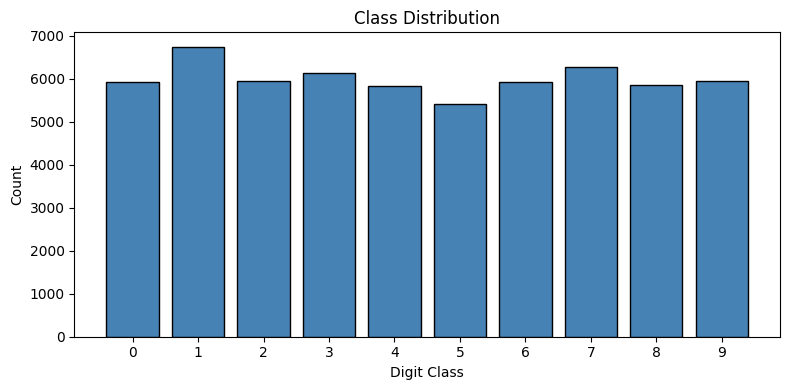

In [67]:
fig, ax = plt.subplots(figsize=(8, 4))
unique, counts = np.unique(y_train_raw, return_counts=True)
ax.bar(unique, counts, color='steelblue', edgecolor='black')
ax.set_xlabel('Digit Class')
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
ax.set_xticks(unique)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [50]:
# Normalise pixels
X_train_norm = X_train_raw.astype(np.float64) / 255.0
X_test_norm  = X_test_raw.astype(np.float64) / 255.0

X_train_cnn = X_train_norm[:, np.newaxis, :, :]
X_test_cnn  = X_test_norm[:, np.newaxis, :, :]

#flatten to 1d for ANN
X_train_ann = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_ann  = X_test_norm.reshape(X_test_norm.shape[0], -1)


def one_hot(y, num_classes=10):
    N = len(y)
    ohe = np.zeros((N, num_classes), dtype=np.float64)
    ohe[np.arange(N), y] = 1.0
    return ohe

y_train_ohe = one_hot(y_train_raw)
y_test_ohe  = one_hot(y_test_raw)

print("CNN Training input shape :", X_train_cnn.shape)
print("ANN Training input shape :", X_train_ann.shape)
print("One-hot labels shape     :", y_train_ohe.shape)

CNN Training input shape : (60000, 1, 28, 28)
ANN Training input shape : (60000, 784)
One-hot labels shape     : (60000, 10)


## 5. Activation Functions

In [51]:
def relu(z):
    return np.maximum(0.0, z)

def relu_grad(z):
    return (z > 0).astype(np.float64)

def softmax(z):
    # z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_grad(z):
    s = sigmoid(z)
    return s * (1.0 - s)

## 6. Loss Function

In [52]:
def cross_entropy_loss(y_pred, y_true):

    N = y_pred.shape[0]
    epsilon = 1e-12   # prevent log(0)
    y_pred_clipped = np.clip(y_pred, epsilon, 1.0 - epsilon)
    loss = -np.sum(y_true * np.log(y_pred_clipped)) / N
    return loss

def cross_entropy_grad(y_pred, y_true):
    N = y_pred.shape[0]
    return (y_pred - y_true) / N

## CNN
### 7.1 Convolutional Layer

In [53]:
class ConvLayer:
    def __init__(self, in_channels, out_channels, kernel_size, lr=0.01):
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.kernel_size  = kernel_size
        self.lr           = lr

        # He initialisation for ReLU networks
        fan_in = in_channels * kernel_size * kernel_size
        std    = np.sqrt(2.0 / fan_in)
        self.W = np.random.randn(out_channels, in_channels, kernel_size, kernel_size) * std
        self.b = np.zeros(out_channels, dtype=np.float64)

    def forward(self, X):
        self.X = X
        N, C_in, H, W = X.shape
        f = self.kernel_size
        H_out = H - f + 1
        W_out = W - f + 1

        Z = np.zeros((N, self.out_channels, H_out, W_out), dtype=np.float64)
        for i in range(H_out):
            for j in range(W_out):
                patch = X[:, :, i:i+f, j:j+f]
                Z[:, :, i, j] = np.tensordot(patch, self.W, axes=([1,2,3],[1,2,3])) + self.b
        self.Z = Z
        self.A = relu(Z)
        return self.A

    def backward(self, dA):
        dZ = dA * relu_grad(self.Z)

        N, C_in, H, W = self.X.shape
        f = self.kernel_size
        H_out = H - f + 1
        W_out = W - f + 1

        dW = np.zeros_like(self.W)
        db = np.zeros_like(self.b)
        dX = np.zeros_like(self.X)

        db = np.sum(dZ, axis=(0, 2, 3))

        for i in range(H_out):
            for j in range(W_out):
                patch = self.X[:, :, i:i+f, j:j+f]
                dW += np.tensordot(dZ[:, :, i, j], patch, axes=([0],[0]))
                dX[:, :, i:i+f, j:j+f] += np.tensordot(dZ[:, :, i, j], self.W, axes=([1],[0]))

        self.W -= self.lr * dW
        self.b -= self.lr * db

        return dX

### 7.2 Max Pooling Layer

In [54]:
class MaxPoolLayer:
    def __init__(self, pool_size=2):
        self.pool_size = pool_size

    def forward(self, X):
        self.X = X
        N, C, H, W = X.shape
        p = self.pool_size
        H_out = H // p
        W_out = W // p

        out = np.zeros((N, C, H_out, W_out), dtype=np.float64)
        for i in range(H_out):
            for j in range(W_out):
                patch = X[:, :, i*p:(i+1)*p, j*p:(j+1)*p]
                out[:, :, i, j] = np.max(patch, axis=(2, 3))
        return out

    def backward(self, dout):
        N, C, H, W = self.X.shape
        p = self.pool_size
        H_out = H // p
        W_out = W // p

        dX = np.zeros_like(self.X)
        for i in range(H_out):
            for j in range(W_out):
                patch = self.X[:, :, i*p:(i+1)*p, j*p:(j+1)*p]
                max_val = np.max(patch, axis=(2, 3), keepdims=True)
                mask = (patch == max_val).astype(np.float64)
                mask /= (np.sum(mask, axis=(2, 3), keepdims=True) + 1e-12)
                dX[:, :, i*p:(i+1)*p, j*p:(j+1)*p] += mask * dout[:, :, i:i+1, j:j+1]
        return dX

### 7.3 Flatten Layer

In [55]:
class FlattenLayer:
    def forward(self, X):
        self.orig_shape = X.shape
        return X.reshape(X.shape[0], -1)

    def backward(self, dout):
        return dout.reshape(self.orig_shape)

### 7.4 Fully Connected (Dense) Layer

In [56]:
class DenseLayer:
    def __init__(self, in_features, out_features, activation='relu', lr=0.01):
        self.activation = activation
        self.lr         = lr

        if activation == 'relu':
            std = np.sqrt(2.0 / in_features)
        else:
            std = np.sqrt(1.0 / in_features)
        self.W = np.random.randn(in_features, out_features) * std
        self.b = np.zeros(out_features, dtype=np.float64)

    def forward(self, X):
        self.X = X
        self.Z = X @ self.W + self.b

        if self.activation == 'relu':
            self.A = relu(self.Z)
        elif self.activation == 'softmax':
            self.A = softmax(self.Z)
        else:
            self.A = self.Z
        return self.A

    def backward(self, dA):
        if self.activation == 'relu':
            dZ = dA * relu_grad(self.Z)
        else:
            dZ = dA

        dW = self.X.T @ dZ
        db = np.sum(dZ, axis=0)
        dX = dZ @ self.W.T

        self.W -= self.lr * dW
        self.b -= self.lr * db

        return dX

### 7.5 CNN Model

In [57]:
np.random.seed(42)

CNN_LR = 0.01

conv1   = ConvLayer(in_channels=1,  out_channels=8,  kernel_size=3, lr=CNN_LR)
pool1   = MaxPoolLayer(pool_size=2)
conv2   = ConvLayer(in_channels=8,  out_channels=16, kernel_size=3, lr=CNN_LR)
pool2   = MaxPoolLayer(pool_size=2)
flatten = FlattenLayer()
fc1     = DenseLayer(in_features=16*5*5, out_features=128, activation='relu',    lr=CNN_LR)
fc2     = DenseLayer(in_features=128,    out_features=10,  activation='softmax', lr=CNN_LR)

cnn_layers = [conv1, pool1, conv2, pool2, flatten, fc1, fc2]

def cnn_forward(X):
    out = X
    for layer in cnn_layers:
        out = layer.forward(out)
    return out

def cnn_backward(y_pred, y_true):
    grad = cross_entropy_grad(y_pred, y_true)
    for layer in reversed(cnn_layers):
        grad = layer.backward(grad)

def count_params(layers):
    total = 0
    for layer in layers:
        if hasattr(layer, 'W'):
            total += layer.W.size + layer.b.size
    return total

print(f"Total CNN Parameters: {count_params(cnn_layers):,}")

Total CNN Parameters: 53,866


## 8. Training the CNN

Training is done using mini-batch stochastic gradient descent (SGD) with cross-entropy loss.

In [58]:
def get_batches(X, y, batch_size):
    N = X.shape[0]
    indices = np.random.permutation(N)
    for start in range(0, N, batch_size):
        idx = indices[start:start + batch_size]
        yield X[idx], y[idx]

def predict(X, forward_fn, batch_size=512):
    preds = []
    for start in range(0, X.shape[0], batch_size):
        batch = X[start:start+batch_size]
        prob  = forward_fn(batch)
        preds.append(np.argmax(prob, axis=1))
    return np.concatenate(preds)

CNN_EPOCHS     = 5
CNN_BATCH_SIZE = 64

cnn_train_losses = []
cnn_train_accs   = []

for epoch in range(1, CNN_EPOCHS + 1):
    t0 = time.time()
    epoch_losses = []

    for Xb, yb in get_batches(X_train_cnn, y_train_ohe, CNN_BATCH_SIZE):
        y_pred = cnn_forward(Xb)
        loss   = cross_entropy_loss(y_pred, yb)
        epoch_losses.append(loss)
        cnn_backward(y_pred, yb)

    avg_loss  = np.mean(epoch_losses)
    train_acc = np.mean(predict(X_train_cnn, cnn_forward) == y_train_raw)
    elapsed   = time.time() - t0

    cnn_train_losses.append(avg_loss)
    cnn_train_accs.append(train_acc)

    print(f"Epoch: {epoch}, Loss: {avg_loss:.4f}, Accuracy: {train_acc*100:.2f}%, Time: {elapsed:.1f}s")

Epoch: 1, Loss: 0.5483, Accuracy: 92.77%, Time: 127.0s
Epoch: 2, Loss: 0.2001, Accuracy: 94.82%, Time: 126.0s
Epoch: 3, Loss: 0.1486, Accuracy: 95.38%, Time: 126.4s
Epoch: 4, Loss: 0.1235, Accuracy: 96.67%, Time: 127.6s
Epoch: 5, Loss: 0.1074, Accuracy: 96.87%, Time: 128.1s


## 9. CNN Test Evaluation

CNN test accuracy: 96.91%


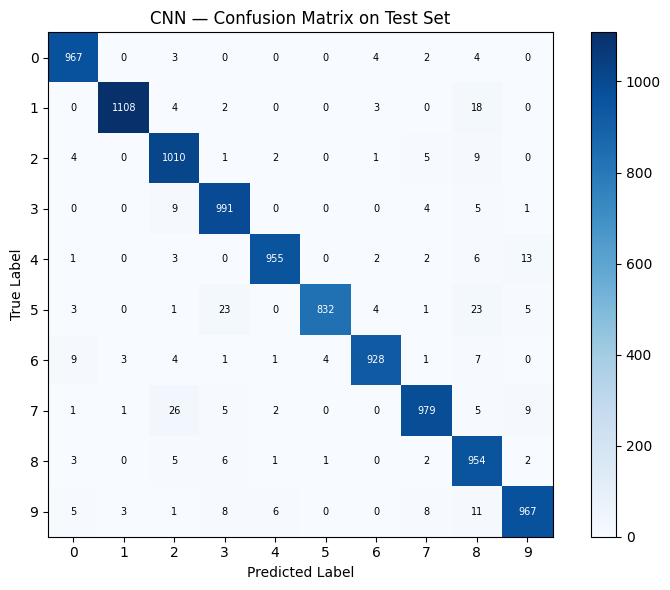

In [59]:
cnn_test_preds = predict(X_test_cnn, cnn_forward)
cnn_test_acc   = np.mean(cnn_test_preds == y_test_raw)
print(f"CNN test accuracy: {cnn_test_acc * 100:.2f}%")

def confusion_matrix(y_true, y_pred, num_classes=10):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

cnn_cm = confusion_matrix(y_test_raw, cnn_test_preds)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cnn_cm, cmap='Blues')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('CNN — Confusion Matrix on Test Set')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        ax.text(j, i, str(cnn_cm[i, j]), ha='center', va='center',
                fontsize=7, color='white' if cnn_cm[i,j] > cnn_cm.max()/2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 10. Plot CNN Training Curves

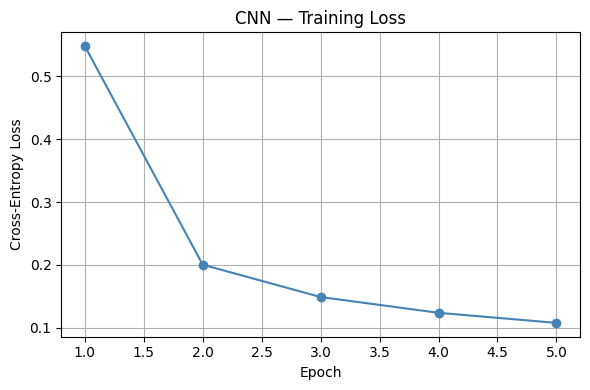

In [68]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(range(1, CNN_EPOCHS+1), cnn_train_losses, marker='o', color='steelblue')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('CNN — Training Loss')
ax.grid(True)

plt.tight_layout()
plt.show()

## 11. ANN

In [61]:
np.random.seed(42)

ANN_LR = 0.01

ann_fc1 = DenseLayer(in_features=784, out_features=256, activation='relu',    lr=ANN_LR)
ann_fc2 = DenseLayer(in_features=256, out_features=128, activation='relu',    lr=ANN_LR)
ann_fc3 = DenseLayer(in_features=128, out_features=64,  activation='relu',    lr=ANN_LR)
ann_fc4 = DenseLayer(in_features=64,  out_features=10,  activation='softmax', lr=ANN_LR)

ann_layers = [ann_fc1, ann_fc2, ann_fc3, ann_fc4]

def ann_forward(X):
    out = X
    for layer in ann_layers:
        out = layer.forward(out)
    return out

def ann_backward(y_pred, y_true):
    grad = cross_entropy_grad(y_pred, y_true)
    for layer in reversed(ann_layers):
        grad = layer.backward(grad)

print(f"Total ANN Parameters: {count_params(ann_layers):,}")

Total ANN Parameters: 242,762


## 12. Training the ANN

In [62]:
ANN_EPOCHS     = 10
ANN_BATCH_SIZE = 128

ann_train_losses = []
ann_train_accs   = []

for epoch in range(1, ANN_EPOCHS + 1):
    t0 = time.time()
    epoch_losses = []

    for Xb, yb in get_batches(X_train_ann, y_train_ohe, ANN_BATCH_SIZE):
        y_pred = ann_forward(Xb)
        loss   = cross_entropy_loss(y_pred, yb)
        epoch_losses.append(loss)
        ann_backward(y_pred, yb)

    avg_loss  = np.mean(epoch_losses)
    train_acc = np.mean(predict(X_train_ann, ann_forward) == y_train_raw)
    elapsed   = time.time() - t0

    ann_train_losses.append(avg_loss)
    ann_train_accs.append(train_acc)

    print(f"Epoch: {epoch}, Loss: {avg_loss}, Accuracy: {train_acc*100:>9.2f}%, Time: {elapsed:>6.1f}s")

Epoch: 1, Loss: 1.2799141577876272, Accuracy:     84.45%, Time:    4.9s
Epoch: 2, Loss: 0.4559658451960267, Accuracy:     89.16%, Time:    3.7s
Epoch: 3, Loss: 0.34352889549550886, Accuracy:     91.01%, Time:    3.7s
Epoch: 4, Loss: 0.29366164224800645, Accuracy:     92.06%, Time:    4.9s
Epoch: 5, Loss: 0.26231528526190384, Accuracy:     92.94%, Time:    3.7s
Epoch: 6, Loss: 0.2383524225161651, Accuracy:     93.43%, Time:    3.7s
Epoch: 7, Loss: 0.21910283507078263, Accuracy:     93.95%, Time:    4.9s
Epoch: 8, Loss: 0.2033075509765643, Accuracy:     94.39%, Time:    3.7s
Epoch: 9, Loss: 0.18969129207122962, Accuracy:     94.66%, Time:    3.9s
Epoch: 10, Loss: 0.17799216475088653, Accuracy:     94.99%, Time:    4.7s


## 13. ANN Test Evaluation

ANN Test Accuracy: 95.01%


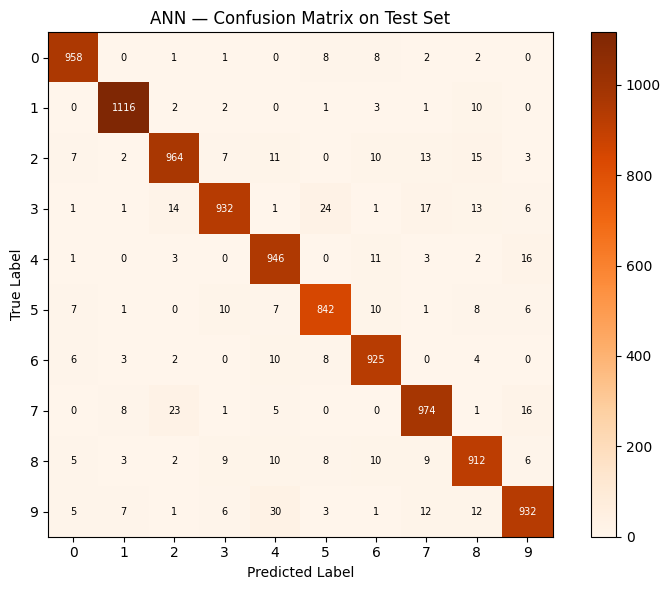

In [63]:
ann_test_preds = predict(X_test_ann, ann_forward)
ann_test_acc   = np.mean(ann_test_preds == y_test_raw)
print(f"ANN Test Accuracy: {ann_test_acc * 100:.2f}%")

ann_cm = confusion_matrix(y_test_raw, ann_test_preds)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(ann_cm, cmap='Oranges')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('ANN — Confusion Matrix on Test Set')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        ax.text(j, i, str(ann_cm[i, j]), ha='center', va='center',
                fontsize=7, color='white' if ann_cm[i,j] > ann_cm.max()/2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 14. Plot ANN Training Curves

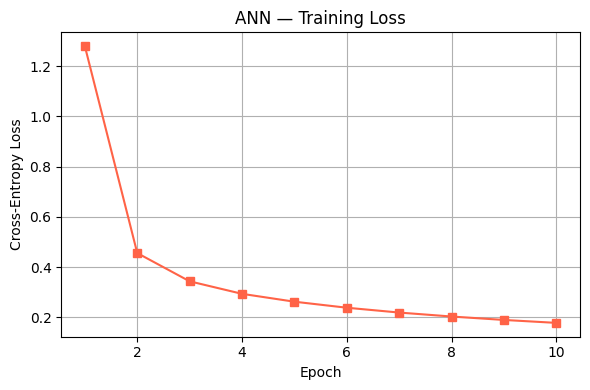

In [70]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(range(1, ANN_EPOCHS+1), ann_train_losses, marker='s', color='tomato')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('ANN — Training Loss')
ax.grid(True)

plt.tight_layout()
plt.show()

## 15. Comparative Report: ANN vs CNN

### 15.1 Quantitative Comparison

In [72]:
cnn_params = count_params(cnn_layers)
ann_params = count_params(ann_layers)

print("CNN:")
print(f"Number of Epochs Trained: {CNN_EPOCHS}")
print(f"Total Parameters: {cnn_params}")
print(f"Train Accuracy: (last epoch): {cnn_train_accs[-1]*100:.2f}%")
print(f"Test Accuracy: {cnn_test_acc*100:.2f}%")

print("\nANN:")
print(f"Number of Epochs Trained: {ANN_EPOCHS}")
print(f"Total Parameters: {ann_params}")
print(f"Train Accuracy: (last epoch): {ann_train_accs[-1]*100:.2f}%")
print(f"Test Accuracy: {ann_test_acc*100:.2f}%")

CNN:
Number of Epochs Trained:5
Total Parameters: 53866
Train Accuracy: (last epoch): 96.87%
Test Accuracy: 96.91%

ANN:
Number of Epochs Trained:10
Total Parameters: 242762
Train Accuracy: (last epoch): 94.99%
Test Accuracy: 95.01%


### 15.2 Visual Comparison of Accuracy

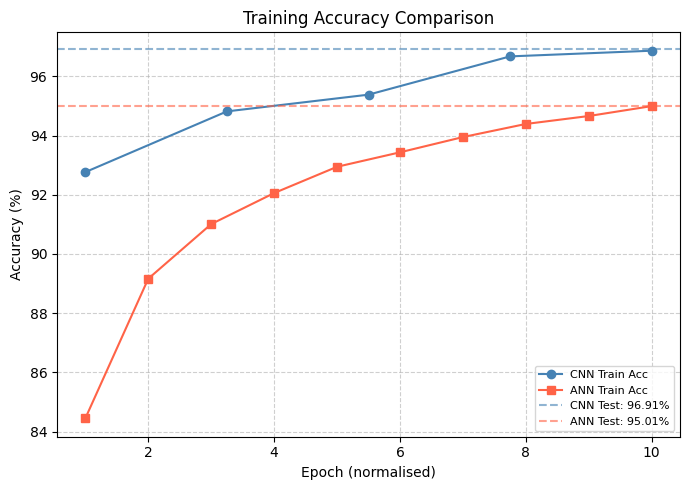

In [74]:
fig, ax = plt.subplots(figsize=(7, 5))

max_e = max(CNN_EPOCHS, ANN_EPOCHS)
cnn_x = np.linspace(1, max_e, CNN_EPOCHS)
ann_x = np.linspace(1, max_e, ANN_EPOCHS)

ax.plot(cnn_x, [a*100 for a in cnn_train_accs], marker='o',
        label='CNN Train Acc', color='steelblue')

ax.plot(ann_x, [a*100 for a in ann_train_accs], marker='s',
        label='ANN Train Acc', color='tomato')

ax.axhline(cnn_test_acc*100, linestyle='--', color='steelblue',
           alpha=0.6, label=f'CNN Test: {cnn_test_acc*100:.2f}%')

ax.axhline(ann_test_acc*100, linestyle='--', color='tomato',
           alpha=0.6, label=f'ANN Test: {ann_test_acc*100:.2f}%')

ax.set_xlabel('Epoch (normalised)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Training Accuracy Comparison')
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()